In [88]:
pip install pandas

In [89]:
import requests
import pandas as pd
from datetime import datetime

url = "https://earthquake.usgs.gov/fdsnws/event/1/query"

all_records = []
start_year = datetime.now().year - 5
end_year = datetime.now().year

for year in range(start_year, end_year + 1):
    for month in range(1, 13):
        start_date = f"{year}-{month:02d}-01"
        if month == 12:
            end_date = f"{year+1}-01-01"
        else:
            end_date = f"{year}-{month+1:02d}-01"

        params = {
            "format": "geojson",
            "starttime": start_date,
            "endtime": end_date,
            "minmagnitude": 3
        }

        response = requests.get(url, params=params)
        if response.status_code != 200:
            print(f"⚠️ Failed for {start_date}: {response.text[:200]}")
            continue

        try:
            data = response.json()
        except Exception as e:
            print(f"⚠️ JSON error for {start_date}: {e}")
            continue

        for f in data["features"]:
            p = f["properties"]
            g = f["geometry"]["coordinates"]
            all_records.append({
                "id":        f.get("id"),
                "ids":       p.get("ids"),
                "net":       p.get("net"),
                "code":      p.get("code"),
                "sources":   p.get("sources"),
                "types":     p.get("types"),
                "type":      p.get("type"),
                "time":      pd.to_datetime(p.get("time"), unit="ms"),
                "updated":   pd.to_datetime(p.get("updated"), unit="ms"),

                "latitude":  g[1] if g else None,
                "longitude": g[0] if g else None,
                "depth_km":  g[2] if g else None,
                "place":     p.get("place"),

                "mag":       p.get("mag"),
                "magType":   p.get("magType"),
                "nst":       p.get("nst"),
                "dmin":      p.get("dmin"),
                "rms":       p.get("rms"),
                "gap":       p.get("gap"),
                "status":    p.get("status"),
                "tsunami":   p.get("tsunami"),
                "alert":     p.get("alert"),
                "felt":      p.get("felt"),
                "cdi":       p.get("cdi"),
                "mmi":       p.get("mmi"),
                "sig":       p.get("sig"),
            })

df = pd.DataFrame(all_records)
df = df[[
    'id', 'time', 'updated', 'latitude', 'longitude', 'depth_km', 'mag',
    'magType', 'place', 'status', 'tsunami', 'alert', 'felt', 'cdi', 'mmi',
    'sig', 'net', 'code', 'ids', 'sources', 'types', 'nst', 'dmin', 'rms',
    'gap', 'type'
]]

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print(df.head())


Rows: 113638
Columns: 26
           id                    time                 updated  latitude  \
0  us6000ddi8 2021-01-31 23:20:49.923 2021-04-16 19:02:44.040  -31.7493   
1  us6000dev6 2021-01-31 23:08:17.161 2021-04-16 19:03:47.040  -15.4902   
2  us6000dev5 2021-01-31 22:54:19.760 2021-04-16 19:03:47.040   19.7529   
3  us6000ddhs 2021-01-31 22:06:00.832 2021-04-16 19:02:43.040   28.1524   
4  us6000dev4 2021-01-31 21:51:14.016 2021-04-16 19:03:46.040   71.3212   

   longitude  depth_km  mag magType  \
0   -68.9337     17.27  4.7     mwr   
1  -177.2052    426.71  4.1      mb   
2   121.3159     46.73  4.7      mb   
3    57.2570     10.00  4.9      mb   
4    -3.7578     10.00  4.0      mb   

                                               place    status  ...  net  \
0        29 km SW of Villa Basilio Nievas, Argentina  reviewed  ...   us   
1                                        Fiji region  reviewed  ...   us   
2                    103 km SW of Basco, Philippines  reviewe

In [141]:
df.columns

Index(['id', 'time', 'updated', 'latitude', 'longitude', 'depth_km', 'mag',
       'magType', 'place', 'status', 'tsunami', 'alert', 'felt', 'cdi', 'mmi',
       'sig', 'net', 'code', 'ids', 'sources', 'types', 'nst', 'dmin', 'rms',
       'gap', 'type', 'region', 'country', 'year', 'month', 'day',
       'day_of_week', 'depth_flag', 'mag_flag'],
      dtype='object')

✅ What You Have Now

Core fields: time, latitude, longitude, depth_km, mag, magType, place

Seismic metadata: status, tsunami, alert, felt, cdi, mmi

Network details: net, code, ids, sources, types

Station quality metrics: nst, dmin, rms, gap

Administrative info: id, updated, type

In [91]:
df.drop_duplicates(inplace=True)
df.head()

,id,time,updated,latitude,longitude,depth_km,mag,magType,place,status,...,net,code,ids,sources,types,nst,dmin,rms,gap,type
0,us6000ddi8,2021-01-31 23:20:49.923,2021-04-16 19:02:44.040,-31.7493,-68.9337,17.27,4.7,mwr,"29 km SW of Villa Basilio Nievas, Argentina",reviewed,...,us,6000ddi8,",us6000ddi8,",",us,",",dyfi,moment-tensor,origin,phase-data,",NaN,0.294,0.82,42.0,earthquake
1,us6000dev6,2021-01-31 23:08:17.161,2021-04-16 19:03:47.040,-15.4902,-177.2052,426.71,4.1,mb,Fiji region,reviewed,...,us,6000dev6,",us6000dev6,",",us,",",origin,phase-data,",NaN,1.471,0.29,64.0,earthquake
2,us6000dev5,2021-01-31 22:54:19.760,2021-04-16 19:03:47.040,19.7529,121.3159,46.73,4.7,mb,"103 km SW of Basco, Philippines",reviewed,...,us,6000dev5,",us6000dev5,",",us,",",origin,phase-data,",NaN,3.057,0.69,106.0,earthquake
3,us6000ddhs,2021-01-31 22:06:00.832,2021-04-16 19:02:43.040,28.1524,57.2570,10.00,4.9,mb,"114 km N of M?n?b, Iran",reviewed,...,us,6000ddhs,",us6000ddhs,",",us,",",origin,phase-data,",NaN,3.330,0.61,71.0,earthquake
4,us6000dev4,2021-01-31 21:51:14.016,2021-04-16 19:03:46.040,71.3212,-3.7578,10.00,4.0,mb,"184 km ENE of Olonkinbyen, Svalbard and Jan Mayen",reviewed,...,us,6000dev4,",us6000dev4,",",us,",",origin,phase-data,",NaN,6.023,0.50,65.0,earthquake


# 1. 	Load Data
###Load the dataset directly from API or CSV into Pandas.
### Convert date/time fields (time, updated) to datetime objects.


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113638 entries, 0 to 113637
Data columns (total 26 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         113638 non-null  object        
 1   time       113638 non-null  datetime64[ns]
 2   updated    113638 non-null  datetime64[ns]
 3   latitude   113638 non-null  float64       
 4   longitude  113638 non-null  float64       
 5   depth_km   113638 non-null  float64       
 6   mag        113638 non-null  float64       
 7   magType    113638 non-null  object        
 8   place      113638 non-null  object        
 9   status     113638 non-null  object        
 10  tsunami    113638 non-null  int64         
 11  alert      4656 non-null    object        
 12  felt       17428 non-null   float64       
 13  cdi        17428 non-null   float64       
 14  mmi        9798 non-null    float64       
 15  sig        113638 non-null  int64         
 16  net        113638 no

In [93]:
print(df.isnull().sum())
print("\nTotal rows:", len(df))

id                0
time              0
updated           0
latitude          0
longitude         0
depth_km          0
mag               0
magType           0
place             0
status            0
tsunami           0
alert        108982
felt          96210
cdi           96210
mmi          103840
sig               0
net               0
code              0
ids               0
sources           0
types             0
nst           27762
dmin           3975
rms              19
gap            3022
type              0
dtype: int64

Total rows: 113638


#2. 	Clean Text Fields
### Use Regex to extract country from place.
 ### Normalize alert field (if exists) to lowercase.
### Ensure all string fields (magType, status, type, net, sources, types) are clean.


In [94]:
if 'alert' in df.columns:
    df['alert'] = df['alert'].str.lower().str.strip()
else:
    print("No 'alert' column found")

In [95]:
string_cols = ['magType', 'status', 'type', 'net', 'sources', 'types']

for col in string_cols:
    if col in df.columns:
        df[col] = (df[col]
                   .str.lower()
                   .str.strip()
                   .str.replace(r'\s+', ' ', regex=True)
                   .str.replace(r'[^\w\s,]', '', regex=True)
                  )
    else:
        print(f"Column '{col}' not found")


In [96]:
print(df.isnull().sum())

id                0
time              0
updated           0
latitude          0
longitude         0
depth_km          0
mag               0
magType           0
place             0
status            0
tsunami           0
alert        108982
felt          96210
cdi           96210
mmi          103840
sig               0
net               0
code              0
ids               0
sources           0
types             0
nst           27762
dmin           3975
rms              19
gap            3022
type              0
dtype: int64


In [97]:
df['place']

,place
0,"29 km SW of Villa Basilio Nievas, Argentina"
1,Fiji region
2,"103 km SW of Basco, Philippines"
3,"114 km N of M?n?b, Iran"
4,"184 km ENE of Olonkinbyen, Svalbard and Jan Mayen"
...,...
113633,"Izu Islands, Japan region"
113634,"Izu Islands, Japan region"
113635,"off the east coast of Honshu, Japan"
113636,"63 km N of Charlotte Amalie, U.S. Virgin Islands"


In [98]:
endings = [ 'region','earthquakes', 'earthquake sequence']

df_filtered = df[df['place'].str.endswith(tuple(endings), na=False)]
print(df_filtered['place'].value_counts())

place
South Sandwich Islands region          3122
Kermadec Islands region                1911
Fiji region                            1296
Izu Islands, Japan region              1036
Volcano Islands, Japan region           438
                                       ... 
Nepal-India border region                 1
Colombia-Ecuador border region            1
western Xizang-India border region        1
Chatham Islands, New Zealand region       1
Cook Islands region                       1
Name: count, Length: 111, dtype: int64


In [99]:

df['place'] = df['place'].str.replace(' region', '', regex=False)
df['place'] = df['place'].str.replace(' earthquakes', '', regex=False)
df['place'] = df['place'].str.replace(' earthquake sequence', '', regex=False)
df['place'] = df['place'].str.replace(' Earthquake', '', regex=False)

df['place'] = df['place'].str.strip()
df['place']

,place
0,"29 km SW of Villa Basilio Nievas, Argentina"
1,Fiji
2,"103 km SW of Basco, Philippines"
3,"114 km N of M?n?b, Iran"
4,"184 km ENE of Olonkinbyen, Svalbard and Jan Mayen"
...,...
113633,"Izu Islands, Japan"
113634,"Izu Islands, Japan"
113635,"off the east coast of Honshu, Japan"
113636,"63 km N of Charlotte Amalie, U.S. Virgin Islands"


In [100]:

df['region'] = df['place'].str.rsplit(',', n=1).str[0].str.strip()
df['country'] = df['place'].str.rsplit(',', n=1).str[-1].str.strip()

df[['region', 'country']]

,region,country
0,29 km SW of Villa Basilio Nievas,Argentina
1,Fiji,Fiji
2,103 km SW of Basco,Philippines
3,114 km N of M?n?b,Iran
4,184 km ENE of Olonkinbyen,Svalbard and Jan Mayen
...,...,...
113633,Izu Islands,Japan
113634,Izu Islands,Japan
113635,off the east coast of Honshu,Japan
113636,63 km N of Charlotte Amalie,U.S. Virgin Islands


In [101]:
endings = [ 'region','earthquakes', 'earthquake sequence']

df_filtered = df[df['place'].str.endswith(tuple(endings), na=False)]
print(df_filtered['place'].value_counts())

Series([], Name: count, dtype: int64)


In [102]:
df[['types']]

,types
0,",dyfi,momenttensor,origin,phasedata,"
1,",origin,phasedata,"
2,",origin,phasedata,"
3,",origin,phasedata,"
4,",origin,phasedata,"
...,...
113633,",internalmomenttensor,internalorigin,losspager..."
113634,",origin,phasedata,"
113635,",origin,phasedata,"
113636,",origin,phasedata,"


In [103]:
df['types'] = df['types'].str.strip(',')

df['types']

,types
0,"dyfi,momenttensor,origin,phasedata"
1,"origin,phasedata"
2,"origin,phasedata"
3,"origin,phasedata"
4,"origin,phasedata"
...,...
113633,"internalmomenttensor,internalorigin,losspager,..."
113634,"origin,phasedata"
113635,"origin,phasedata"
113636,"origin,phasedata"


#3 Clean Numeric Fields
### Convert mag, depth_km, nst, dmin, rms, gap, magError, depthError, magNst, sig to numeric.
### Fill missing numeric values with 0 or median if needed.


In [104]:
numeric_cols = ['mag', 'depth_km', 'nst', 'dmin', 'rms', 'gap']

In [105]:
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    else:
        print(f"Column '{col}' not found")

### missing values

In [106]:
print(df[numeric_cols].isnull().sum())

mag             0
depth_km        0
nst         27762
dmin         3975
rms            19
gap          3022
dtype: int64


In [107]:

df['dmin'] = df['dmin'].fillna(df['dmin'].median())
df['rms']  = df['rms'].fillna(df['rms'].median())
df['gap']  = df['gap'].fillna(df['gap'].median())
print(df[['dmin', 'rms', 'gap']].isnull().sum())

dmin    0
rms     0
gap     0
dtype: int64


In [108]:
zero_fill_cols = ['nst', 'magNst', 'tsunami', 'felt']
for col in zero_fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)


In [109]:
print(df.isnull().sum())

id                0
time              0
updated           0
latitude          0
longitude         0
depth_km          0
mag               0
magType           0
place             0
status            0
tsunami           0
alert        108982
felt              0
cdi           96210
mmi          103840
sig               0
net               0
code              0
ids               0
sources           0
types             0
nst               0
dmin              0
rms               0
gap               0
type              0
region            0
country           0
dtype: int64


#4. 	Add Derived Columns
### Year, month, day, day_of_week from time.
### Shallow/deep earthquake flag based on depth_km.
### Strong/destructive flag based on mag thresholds.


In [110]:
df['time'] = pd.to_datetime(df['time'])
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month_name()
df['day'] = df['time'].dt.day
df['day_of_week'] = df['time'].dt.day_name()

In [111]:
df['depth_flag']=df['depth_km'].apply(lambda x: 'Shallow' if x<70 else 'Deep')

In [112]:
df['mag_flag']=df['mag'].apply(lambda x:
    'Weak' if x<4 else
    'Strong' if x<6 else
    'Destructive'
)

In [113]:
df.isnull().sum()

,0
id,0
time,0
updated,0
latitude,0
longitude,0
depth_km,0
mag,0
magType,0
place,0
status,0


In [114]:
df['alert']

,alert
0,None
1,None
2,None
3,None
4,None
...,...
113633,green
113634,None
113635,None
113636,None


In [115]:
df['mmi'].describe()

,mmi
count,9798.000000
mean,3.275773
std,1.610759
min,0.000000
25%,2.381500
50%,3.412500
75%,4.129000
max,9.953000


<Axes: >

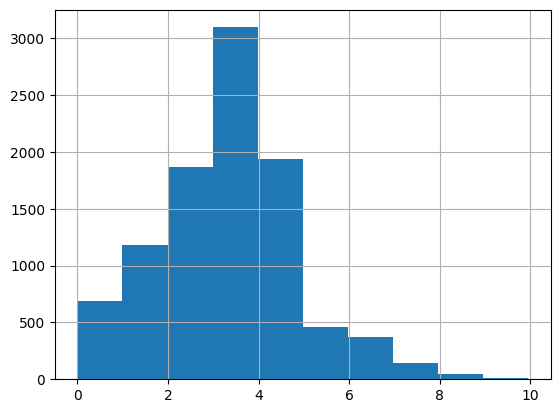

In [116]:
df['mmi'].hist()

### cdi → Community Decimal Intensity (0-10 scale) → fill with median


In [117]:
df['cdi'] = df['cdi'].fillna(df['cdi'].median())


### mmi → Modified Mercalli Intensity (0-10 scale) → fill with median

In [118]:
df['mmi'] = df['mmi'].fillna(df['mmi'].median())

### alert → categorical/text column → fill with 'unknown'


In [119]:
df['alert'] = df['alert'].fillna(df['alert'].mode()[0])

In [120]:
print(df[['alert', 'cdi', 'mmi']].isnull().sum())

alert    0
cdi      0
mmi      0
dtype: int64


In [121]:
df['tsunami']

,tsunami
0,0
1,0
2,0
3,0
4,0
...,...
113633,0
113634,0
113635,0
113636,0


<Axes: >

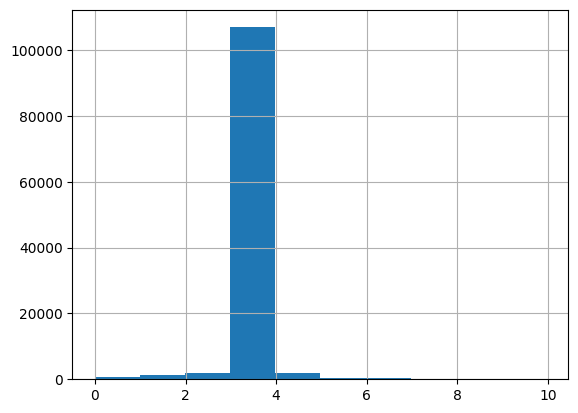

In [122]:
df['mmi'].hist()

In [123]:
df.isnull().value_counts()

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,count
id,time,updated,latitude,longitude,depth_km,mag,magType,place,status,tsunami,alert,felt,cdi,mmi,sig,net,code,ids,sources,types,nst,dmin,rms,gap,type,region,country,year,month,day,day_of_week,depth_flag,mag_flag,
False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,113638


In [124]:
df.dtypes

,0
id,object
time,datetime64[ns]
updated,datetime64[ns]
latitude,float64
longitude,float64
depth_km,float64
mag,float64
magType,object
place,object
status,object


In [125]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
time,113638,2023-09-21 18:31:26.193282048,2021-01-01 00:14:07.580000,2022-04-19 14:03:03.788500224,2023-09-28 02:26:15.608499968,2025-03-03 11:36:22.404499968,2026-06-18 10:28:05.420000,NaN
updated,113638,2024-01-08 14:09:16.411772160,2021-01-01 10:15:32.601000,2022-08-13 21:51:42.289999872,2024-01-18 21:14:49.793499904,2025-06-27 00:34:20.040000,2026-06-18 10:56:24.040000,NaN
latitude,113638.0,12.115644,-84.4932,-14.6963,14.999,39.06955,87.3752,32.020223
longitude,113638.0,7.32869,-179.9997,-113.916025,24.02965,130.520225,179.9994,129.021693
depth_km,113638.0,71.906288,-3.74,10.0,21.585,71.1305,683.578,123.346407
mag,113638.0,4.256392,3.0,4.0,4.3,4.6,8.8,0.610104
tsunami,113638.0,0.005799,0.0,0.0,0.0,0.0,1.0,0.075931
felt,113638.0,15.156515,0.0,0.0,0.0,0.0,184666.0,670.363504
cdi,113638.0,3.119134,0.0,3.1,3.1,3.1,9.1,0.591625
mmi,113638.0,3.400711,0.0,3.4125,3.4125,3.4125,9.953,0.474507


# checking the negative values

In [126]:
print("Invalid lot",(~df["longitude"].between(-180, 180)).sum())

Invalid lot 0


In [127]:
print("Invalid mag:", (~df["mag"].between(0, 10)).sum())

Invalid mag: 0


In [128]:
print("Invalid lat:", (~df["latitude"].between(-90, 90)).sum())

Invalid lat: 0


In [129]:
print("Invalid tsunami:", (~df["tsunami"].isin([0, 1])).sum())

Invalid tsunami: 0


In [130]:
print("Negative depth:", (df["depth_km"] < 0).sum())

Negative depth: 107


In [131]:
df = df[df["depth_km"] >= 0]
len(df)

113531

In [132]:
df.shape

(113531, 34)

In [133]:
df.columns

Index(['id', 'time', 'updated', 'latitude', 'longitude', 'depth_km', 'mag',
       'magType', 'place', 'status', 'tsunami', 'alert', 'felt', 'cdi', 'mmi',
       'sig', 'net', 'code', 'ids', 'sources', 'types', 'nst', 'dmin', 'rms',
       'gap', 'type', 'region', 'country', 'year', 'month', 'day',
       'day_of_week', 'depth_flag', 'mag_flag'],
      dtype='object')

In [134]:
df.index

Index([     0,      1,      2,      3,      4,      5,      6,      7,      8,
            9,
       ...
       113628, 113629, 113630, 113631, 113632, 113633, 113634, 113635, 113636,
       113637],
      dtype='int64', length=113531)

In [143]:
df['mag_flag'].value_counts()

,count
mag_flag,
Strong,87784
Weak,25007
Destructive,740


In [135]:
df[['day_of_week','day','month']]

,day_of_week,day,month
0,Sunday,31,January
1,Sunday,31,January
2,Sunday,31,January
3,Sunday,31,January
4,Sunday,31,January
...,...,...,...
113633,Monday,1,June
113634,Monday,1,June
113635,Monday,1,June
113636,Monday,1,June


In [136]:
df.to_csv("earthquake_clean.csv", index=False)
print("✅ Cleaned data saved!")

✅ Cleaned data saved!


In [137]:
from google.colab import files
files.download('earthquake_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [139]:
df.shape

(113531, 34)

| Parameter         | Practical Limit                    | Recommendation                    |
| ----------------- | ---------------------------------- | --------------------------------- |
| Records per query | ~20,000                            | Split by date or region           |
| Request size      | ~50–100 MB                         | Use compressed CSV/JSON           |
| Pagination        | Supported via `limit` and `offset` | Use for smaller incremental pulls |
| Best practice     | Monthly or regional slices         | Combine results in Pandas         |
